# 03 - Part C: the port seen from 22.5 deg to the right, 100 cm away

> *"Use homography perspective to code an output image of the port from a view
> that's from a slightly right side, 100 cm away from the port's centre looking
> directly at it, at an angle of 22.5 degrees."*

The scene is fully specified by the assignment: a **40 x 40 cm** planar port, a
camera on a **100 cm** sphere around its centre, **looking directly at it**, at
**22.5 deg** to the right. The only thing *not* specified is the camera's
intrinsics -- and section 6 shows that, under the look-at constraint, the missing
intrinsics do not affect the geometry of the result at all, only its pixel scale
and framing. That is the key point of this notebook.

Contents: candidate models (including the one I rejected and why) -> frames and
look-at -> the plane-induced homography with its sign derived -> rendering ->
closed-form predictions checked two ways -> intrinsics invariance -> Model B ->
limitations.

In [1]:
# --- Setup: locate the project, check dependencies, import the package -------
# Local Jupyter: the project is found by walking up from the working directory.
# Google Colab: Drive is mounted and searched for the project folder. A folder
# that cannot be written to (for example one shared as view-only) is copied to
# /content first, so the notebook can save its outputs.
import glob, importlib.util, os, shutil, subprocess, sys

PROJECT_NAME = "AULE_ComputerVisionChallenge"
PROJECT_DIR = ""  # optional: set this to the project folder if it is not found automatically

def _is_project(path):
    return bool(path) and os.path.isdir(os.path.join(path, "src", "aulecv"))

def _walk_up(start):
    path = os.path.abspath(start)
    while not _is_project(path):
        parent = os.path.dirname(path)
        if parent == path:
            return None
        path = parent
    return path

def _is_writable(path):
    probe = os.path.join(path, "outputs", ".write_test")
    try:
        os.makedirs(os.path.dirname(probe), exist_ok=True)
        with open(probe, "w") as fh:
            fh.write("ok")
        os.remove(probe)
        return True
    except OSError:
        return False

IN_COLAB = "google.colab" in sys.modules
PROJECT_ROOT = PROJECT_DIR if _is_project(PROJECT_DIR) else _walk_up(os.getcwd())

if PROJECT_ROOT is None and IN_COLAB:
    local_copy = os.path.join("/content", PROJECT_NAME)
    if _is_project(local_copy):
        PROJECT_ROOT = local_copy
    else:
        from google.colab import drive
        drive.mount("/content/drive")
        patterns = ["MyDrive/{}", "MyDrive/*/{}", "MyDrive/*/*/{}",
                    ".shortcut-targets-by-id/*/{}", ".shortcut-targets-by-id/*/*/{}",
                    "Shareddrives/*/{}"]
        found = [p for pat in patterns
                 for p in sorted(glob.glob(os.path.join("/content/drive", pat.format(PROJECT_NAME))))
                 if _is_project(p)]
        if not found:
            raise RuntimeError(
                "The {0} folder was not found in Google Drive. If it was shared with you, "
                "open Drive, right-click the shared folder and choose Organize > Add shortcut "
                "> My Drive, then run this cell again. Alternatively set PROJECT_DIR above."
                .format(PROJECT_NAME))
        PROJECT_ROOT = found[0]
        if not _is_writable(PROJECT_ROOT):
            shutil.copytree(PROJECT_ROOT, local_copy, dirs_exist_ok=True)
            print("Drive folder is read-only; working on a copy in", local_copy)
            PROJECT_ROOT = local_copy

if PROJECT_ROOT is None:
    raise RuntimeError("Could not find the {} folder. Open this notebook from inside it, "
                       "or set PROJECT_DIR above.".format(PROJECT_NAME))

_required = {"cv2": "opencv-python-headless", "numpy": "numpy", "pandas": "pandas",
             "matplotlib": "matplotlib", "imageio": "imageio", "PIL": "pillow"}
_missing = [pkg for mod, pkg in _required.items() if importlib.util.find_spec(mod) is None]
if _missing and IN_COLAB:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + _missing)
elif _missing:
    raise ImportError("Missing packages: {}. Install them with: pip install -r "
                      "requirements.txt".format(", ".join(_missing)))

os.environ["AULECV_PROJECT_ROOT"] = PROJECT_ROOT
if os.path.join(PROJECT_ROOT, "src") not in sys.path:
    sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))

import numpy as np, cv2, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=4, suppress=True)

from aulecv import config as C, detect, rotation, navigation, camera, viz
from aulecv import io as aio

np.random.seed(C.RANDOM_SEED)
OUT = aio.ensure_output_dirs()
print("PROJECT_ROOT :", PROJECT_ROOT)
print("outputs      :", OUT)
print("python       :", sys.version.split()[0], "| opencv", cv2.__version__, "| numpy", np.__version__)

PROJECT_ROOT : D:\Aulespace\AULE_ComputerVisionChallenge
outputs      : D:\Aulespace\AULE_ComputerVisionChallenge\outputs
python       : 3.14.3 | opencv 4.13.0 | numpy 2.4.3


In [2]:
reference = aio.load_reference()
ref_det = detect.detect_port(reference)
geom = camera.PortGeometry.from_detection(ref_det, reference.shape)

print("detected outer quad (canonical order)")
print(np.round(geom.raster_corners, 3))
print()
print("raster port size          : {:.2f} x {:.2f} px  (aspect {:.4f})"
      .format(geom.width_px, geom.height_px, geom.width_px / geom.height_px))
print("physical port size        : {:.1f} x {:.1f} cm   (given)"
      .format(geom.side_cm, geom.side_cm))
print("camera distance           : {:.1f} cm            (given)".format(geom.distance_cm))
print("Model A focal length      : {:.3f} px  = {:g} * sqrt(w*h)"
      .format(geom.metric_focal_px, C.FOCAL_SCALE))
print("Model B focal lengths     : fx {:.3f}, fy {:.3f} px"
      .format(*geom.image_faithful_focal_px))

detected outer quad (canonical order)
[[ 31.  24.]
 [581.  24.]
 [581. 542.]
 [ 31. 542.]]

raster port size          : 550.00 x 518.00 px  (aspect 1.0618)
physical port size        : 40.0 x 40.0 cm   (given)
camera distance           : 100.0 cm            (given)
Model A focal length      : 1334.401 px  = 2.5 * sqrt(w*h)
Model B focal lengths     : fx 1375.000, fy 1295.000 px


## 1. Candidate models, and the one I rejected

| Model | Plane geometry | Output camera | Output at theta = 0 | Verdict |
|---|---|---|---|---|
| **v1** | back-project the raster corners with `fx = fy` | square pixels | identical to the raster | **Rejected** -- see below |
| **A: metric-faithful** | the given 40 x 40 cm square | square pixels | the *rectified* (square) port | **Primary** |
| **B: image-faithful** | 40 x 40 cm square, absorbed into `fx != fy` | non-square pixels | *identical* to the raster | Secondary, shown alongside |
| C: rectify first, then project | 40 x 40 cm | square pixels | rectified | Same thing as A -- it *is* A's implementation |
| D: redraw a clean CAD model from 40/35/30 | metric | any | clean | Rejected: throws away the supplied image, and the marker's size and position are underdetermined by the text |

### Why v1 is wrong, in one number

v1 is the tempting shortcut: take the raster's detected outer corners, back-project
them at 100 cm with `fx = fy = f`, and call the result the port. It buys
`H(0) = I` -- the theta = 0 output is byte-identical to the input, which *looks*
like a strong correctness check.

It is not. Let us compute what object it implies.

In [3]:
f_v1 = geom.metric_focal_px          # any square-pixel focal length; the ratio is what matters
w_cm_v1 = geom.width_px * geom.distance_cm / f_v1
h_cm_v1 = geom.height_px * geom.distance_cm / f_v1
print("v1 back-projection at {:.0f} cm with fx = fy = {:.1f} px implies a port of"
      .format(geom.distance_cm, f_v1))
print("    {:.2f} cm x {:.2f} cm".format(w_cm_v1, h_cm_v1))
print("the assignment says                      {:.2f} cm x {:.2f} cm"
      .format(geom.side_cm, geom.side_cm))
print()
print("=> v1 silently contradicts the given geometry by {:+.2f} cm in width and"
      " {:+.2f} cm in height.".format(w_cm_v1 - geom.side_cm, h_cm_v1 - geom.side_cm))
print("   It bought H(0) = I by making the port rectangular. Rejected.")
print()
print("Model A instead keeps the 40 x 40 cm square and lets the raster be its")
print("TEXTURE, attached by a 4-point homography G. Nothing about the drawing's")
print("6% rectangularity leaks into the physical model.")

v1 back-projection at 100 cm with fx = fy = 1334.4 px implies a port of
    41.22 cm x 38.82 cm
the assignment says                      40.00 cm x 40.00 cm

=> v1 silently contradicts the given geometry by +1.22 cm in width and -1.18 cm in height.
   It bought H(0) = I by making the port rectangular. Rejected.

Model A instead keeps the 40 x 40 cm square and lets the raster be its
TEXTURE, attached by a 4-point homography G. Nothing about the drawing's
6% rectangularity leaks into the physical model.


## 2. Frames, and the look-at rotation (derivation)

World origin at the port centre, $X$ right, $Y$ **down**, $Z$ away from the
frontal camera *into* the port, so the port plane is $Z = 0$. The reference
camera is at $C_0 = (0,0,-100)$ and the orbit is

$$ C(\theta) = (100\sin\theta,\; 0,\; -100\cos\theta) $$

with $\theta > 0$ = the viewer's right.

"Looking directly at it" pins the optical axis but **not the roll about it**.
Assumption, stated once: **zero roll** -- the camera stays level, i.e. its
image-down axis stays in the vertical plane containing world-down. So, with
`world_down = (0,1,0)`:

$$ z_c = \frac{O-C}{\lVert O-C\rVert},\qquad
   x_c = \frac{\text{world\_down} \times z_c}{\lVert\cdot\rVert},\qquad
   y_c = z_c \times x_c $$
$$ R_{wc} = [\,x_c^\top;\; y_c^\top;\; z_c^\top\,], \qquad t = -R_{wc}C $$

In [4]:
print("pose checks across the orbit (all MEASURED, none assumed):")
print(" theta    det R      ||R^T R - I||   ||C||        axis||-C     t")
for th in (0.0, 5.0, 11.25, 22.5, 45.0, -22.5):
    p = camera.camera_pose_for_angle(th)
    R, t, Cc = p["R"], p["t"], p["C"]
    axis_err = float(np.linalg.norm(np.cross(R[2, :], -Cc)))
    print("{:7.2f}  {:.12f}  {:.3e}     {:.9f}  {:.3e}   {}"
          .format(th, float(np.linalg.det(R)),
                  float(np.linalg.norm(R.T @ R - np.eye(3))),
                  float(np.linalg.norm(Cc)), axis_err, np.round(t, 9)))
print()
R0 = camera.camera_pose_for_angle(0.0)["R"]
print("R(0) == I exactly :", bool(np.array_equal(R0, np.eye(3))) or
      "within {:.1e}".format(float(np.abs(R0 - np.eye(3)).max())))
print("R(22.5) =")
print(np.round(camera.camera_pose_for_angle(22.5)["R"], 8))
print("\nt is (0, 0, 100) for EVERY theta -- the camera is always 100 cm along")
print("its own optical axis, which is exactly the constraint we were given.")

pose checks across the orbit (all MEASURED, none assumed):
 theta    det R      ||R^T R - I||   ||C||        axis||-C     t
   0.00  1.000000000000  0.000e+00     100.000000000  0.000e+00   [  0.   0. 100.]
   5.00  1.000000000000  5.439e-16     100.000000000  0.000e+00   [  0.   0. 100.]
  11.25  1.000000000000  3.216e-16     100.000000000  0.000e+00   [ -0.   0. 100.]
  22.50  1.000000000000  3.060e-17     100.000000000  0.000e+00   [  0.   0. 100.]
  45.00  1.000000000000  5.472e-16     100.000000000  0.000e+00   [ -0.   0. 100.]
 -22.50  1.000000000000  3.060e-17     100.000000000  0.000e+00   [ -0.   0. 100.]

R(0) == I exactly : True
R(22.5) =
[[ 0.9239 -0.      0.3827]
 [ 0.      1.      0.    ]
 [-0.3827  0.      0.9239]]

t is (0, 0, 100) for EVERY theta -- the camera is always 100 cm along
its own optical axis, which is exactly the constraint we were given.


## 3. The plane-induced homography, with the sign *derived*

Write a plane point in the **reference** camera frame as $X_0 = X_w + t_0$ with
$t_0 = (0,0,100)$. The port plane $Z_w = 0$ becomes

$$ n^\top X_0 = d,\qquad n = (0,0,1),\; d = +100 $$

In the rotated camera frame $X_\theta = R X_w + t = R X_0 + (t - R t_0)$. Set
$t_{rel} = t - R t_0$. On the plane $n^\top X_0 / d = 1$, so

$$ X_\theta = \left(R + \frac{t_{rel} n^\top}{d}\right) X_0
   \;\;\Longrightarrow\;\;
   \boxed{\,H = K\left(R + \frac{t_{rel}\,n^\top}{d}\right)K^{-1}\,} $$

a **PLUS** sign. The familiar minus sign (Hartley & Zisserman) belongs to the
other plane convention, $n^\top X + d = 0$.

Rather than assert it, compare it against the *independently composed*
$K[r_1\,r_2\,t](\theta)\,\bigl(K[r_1\,r_2\,t](0)\bigr)^{-1}$, and print the
distance for the minus sign too so the difference is visible.

In [5]:
K_probe = camera.estimate_camera_intrinsics(geom.metric_focal_px, principal_point=(0.0, 0.0))
rows = []
for th in (2.5, 7.5, 11.25, 22.5, 45.0, -22.5):
    chk = camera.homography_sign_check(K_probe, th, geom.distance_cm)
    rows.append({"theta_deg": th,
                 "t_rel": np.round(chk["t_rel"], 6),
                 "dist_PLUS": chk["distance_plus"],
                 "dist_MINUS": chk["distance_minus"],
                 "plus_wins": chk["plus_wins"]})
sign = pd.DataFrame(rows)
display(sign)
print("distance = scale-normalised Frobenius norm between the two 3x3 matrices.")
print("PLUS  agrees with the composed homography to {:.3e} (machine precision)."
      .format(sign['dist_PLUS'].max()))
print("MINUS is off by {:.3f}. The sign is confirmed numerically, not assumed."
      .format(sign['dist_MINUS'].min()))

,theta_deg,t_rel,dist_PLUS,dist_MINUS,plus_wins
0,2.50,"[-4.361939, 0.0, 0.095178]",1.554484e-15,1.403665,True
1,7.50,"[-13.052619, 0.0, 0.855514]",4.391740e-15,1.410724,True
2,11.25,"[-19.509032, 0.0, 1.921472]",1.523140e-15,1.411905,True
3,22.50,"[-38.268343, 0.0, 7.612047]",5.104417e-15,1.413106,True
4,45.00,"[-70.710678, 0.0, 29.289322]",1.552622e-14,1.413760,True
5,-22.50,"[38.268343, 0.0, 7.612047]",5.104417e-15,1.415320,True


distance = scale-normalised Frobenius norm between the two 3x3 matrices.
PLUS  agrees with the composed homography to 1.553e-14 (machine precision).
MINUS is off by 1.404. The sign is confirmed numerically, not assumed.


In [6]:
chk = camera.homography_sign_check(K_probe, C.PART_C_ANGLE_DEG, geom.distance_cm)
print("at theta = 22.5 deg")
print("\nanalytic  K (R + t_rel n^T / d) K^-1  (normalised):")
print(np.round(camera.normalize_homography(chk["H_analytic_plus"]), 8))
print("\ncomposed  K[r1 r2 t](22.5) (K[r1 r2 t](0))^-1  (normalised):")
print(np.round(camera.normalize_homography(chk["H_composed"]), 8))
print("\nmax elementwise difference: {:.3e}"
      .format(float(np.abs(camera.normalize_homography(chk["H_analytic_plus"])
                           - camera.normalize_homography(chk["H_composed"])).max())))

at theta = 22.5 deg

analytic  K (R + t_rel n^T / d) K^-1  (normalised):
[[ 0.5469  0.      0.    ]
 [ 0.      0.592   0.    ]
 [-0.0002  0.      0.592 ]]

composed  K[r1 r2 t](22.5) (K[r1 r2 t](0))^-1  (normalised):
[[ 0.5469  0.      0.    ]
 [ 0.      0.592   0.    ]
 [-0.0002  0.      0.592 ]]

max elementwise difference: 5.104e-15


## 4. Model A: build G, then render

$G$ maps raster pixels to plane centimetres by sending the four detected outer
corners to $(\pm 20, \pm 20)$. Then, for each pose,

$$ H_A(\theta) = K\,[\,r_1\; r_2\; t\,](\theta)\; G $$

A **single warp of the original raster** per frame. The canvas is sized once,
from the union of the projected quads over the whole Part D sweep, so Part C's
frame and Part D's frames live in the same coordinate system.

In [7]:
G = camera.raster_to_plane_homography(geom.raster_corners, geom.side_cm)
print("G (raster px -> plane cm):"); print(np.round(G, 8))
print()
print("G maps the detected corners to:")
print(np.round(camera.project_points(G, geom.raster_corners), 9))
print("target (the physical square):")
print(np.round(geom.plane_corners_cm, 9))
print("\nmax error: {:.3e} cm"
      .format(float(np.abs(camera.project_points(G, geom.raster_corners)
                           - geom.plane_corners_cm).max())))

thetas = camera.generate_return_sequence(C.PART_C_ANGLE_DEG, C.PART_D_STEP_DEG)
renderA = camera.make_renderer(geom, thetas, "metric")
renderB = camera.make_renderer(geom, thetas, "image_faithful")
print("\nshared canvas (Model A) : {} x {} px".format(*renderA.canvas))
print("K_A ="); print(np.round(renderA.K, 4))
print("square pixels: fx == fy ->", renderA.K[0, 0] == renderA.K[1, 1])

G (raster px -> plane cm):
[[  0.0727   0.     -22.2545]
 [  0.       0.0772 -21.8533]
 [  0.       0.       1.    ]]

G maps the detected corners to:
[[-20. -20.]
 [ 20. -20.]
 [ 20.  20.]
 [-20.  20.]]
target (the physical square):
[[-20. -20.]
 [ 20. -20.]
 [ 20.  20.]
 [-20.  20.]]

max error: 8.234e-07 cm

shared canvas (Model A) : 632 x 671 px
K_A =
[[1334.4006    0.      313.12  ]
 [   0.     1334.4006  335.239 ]
 [   0.        0.        1.    ]]
square pixels: fx == fy -> True


H_A(22.5) (raster px -> canvas px):
[[ 0.7459  0.     60.2922]
 [-0.086   0.9496 66.5145]
 [-0.0003  0.      1.    ]]

rendered: (671, 632, 3) -> D:\Aulespace\AULE_ComputerVisionChallenge\outputs\side_view_22_5.png


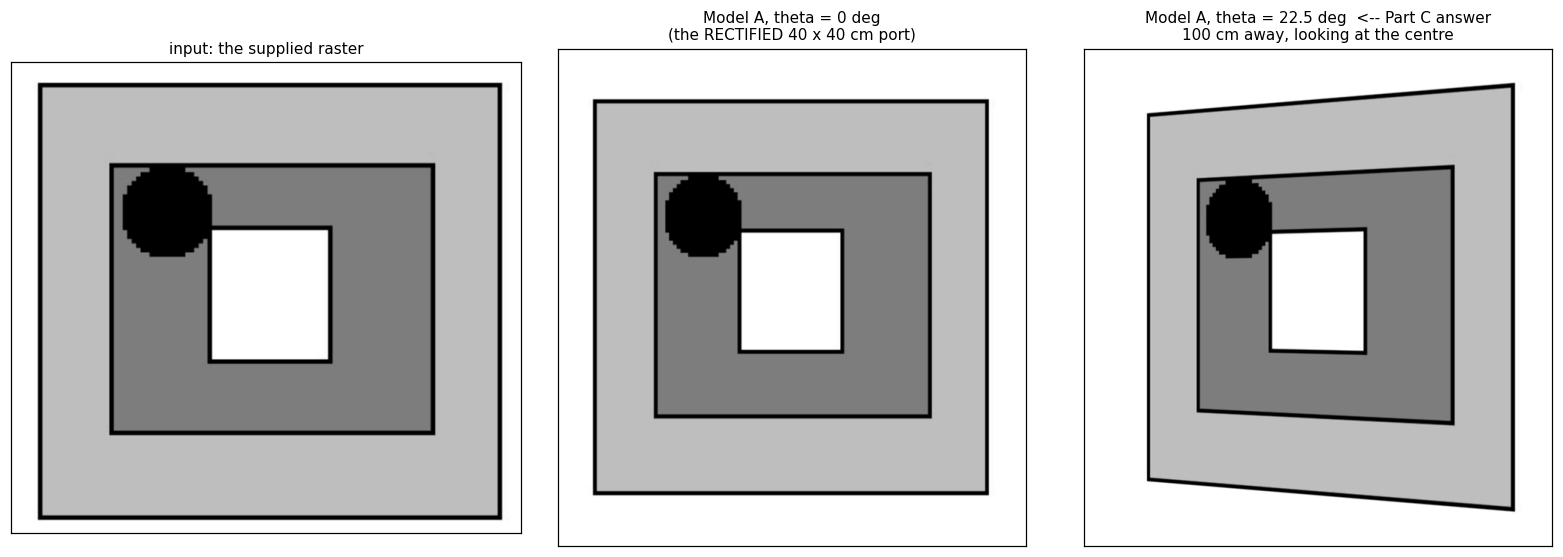

In [8]:
H_A = renderA.homography(C.PART_C_ANGLE_DEG)
view_A = renderA.render(reference, C.PART_C_ANGLE_DEG)
view_front = renderA.render(reference, 0.0)

aio.save_image(aio.output_path("side_view_22_5.png"), view_A)
aio.save_image(aio.output_path("homography", "front_view_rectified.png"), view_front)

print("H_A(22.5) (raster px -> canvas px):"); print(np.round(H_A, 8))
print("\nrendered:", view_A.shape, "->", aio.output_path("side_view_22_5.png"))

fig, axes = plt.subplots(1, 3, figsize=(14.5, 5.0))
viz.show(reference, "input: the supplied raster", ax=axes[0])
viz.show(view_front, "Model A, theta = 0 deg\n(the RECTIFIED 40 x 40 cm port)", ax=axes[1])
viz.show(view_A, "Model A, theta = 22.5 deg  <-- Part C answer\n"
                 "100 cm away, looking at the centre", ax=axes[2])
fig.tight_layout()
fig.savefig(aio.output_path("homography", "part_c_overview.png"), bbox_inches="tight", dpi=110)
plt.show()

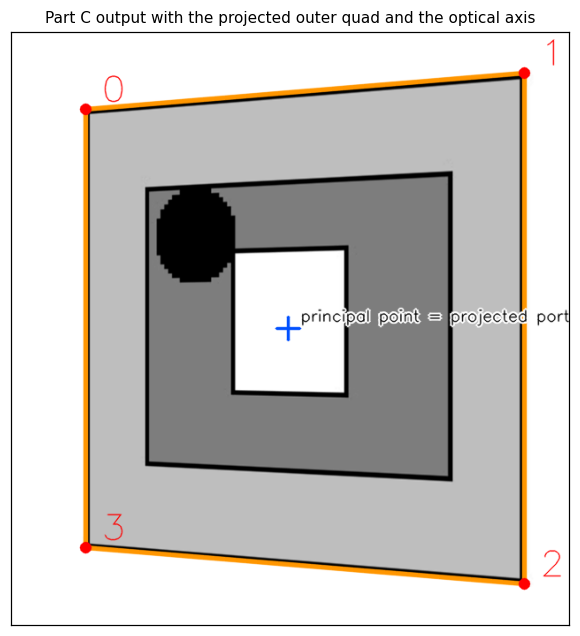

In [9]:
annotated = view_A.copy()
q_proj = renderA.project_port_corners(C.PART_C_ANGLE_DEG)
viz.draw_quad(annotated, q_proj, label_corners=True)
pp = np.round(renderA.K[:2, 2]).astype(int)
cv2.drawMarker(annotated, tuple(pp), (255, 80, 0), cv2.MARKER_CROSS, 26, 2, cv2.LINE_AA)
annotated = viz.annotate(annotated, "principal point = projected port centre", (pp[0] + 14, pp[1] - 8))
aio.save_image(aio.output_path("homography", "side_view_22_5_annotated.png"), annotated)
viz.show(annotated, "Part C output with the projected outer quad and the optical axis",
         figsize=(7.2, 7.0))
plt.show()

## 5. Closed-form physical predictions, checked two ways

These come from the geometry alone and are computed **without touching the
rendering code**, so they are a genuine external check.

The vertical edges sit at constant depth:

$$ (P - C)\cdot z_c = R \mp \tfrac{L}{2}\sin\theta $$

so the $+X$ (right) edge is the **near** one for $\theta>0$, and because the
depth is constant along each edge, its projected height is exactly $fL/\text{depth}$.
The ratio is therefore depth-only -- independent of $f$ and of the principal point:

$$ \frac{h_{\text{near}}}{h_{\text{far}}}
  = \frac{R + \tfrac{L}{2}\sin\theta}{R - \tfrac{L}{2}\sin\theta} $$

Check (a) against the projection, and check (b) by **re-detecting the corners on
the rendered pixels**.

In [10]:
depths = camera.predicted_edge_depths_cm(C.PART_C_ANGLE_DEG, geom.side_cm, geom.distance_cm)
pred = camera.predicted_edge_height_ratio(C.PART_C_ANGLE_DEG, geom.side_cm, geom.distance_cm)
print("CLOSED FORM at theta = 22.5 deg")
print("  depth of the +X (right, near) edge : {:.6f} cm".format(depths["right_near_cm"]))
print("  depth of the -X (left,  far)  edge : {:.6f} cm".format(depths["left_far_cm"]))
print("  predicted near/far height ratio    : {:.6f}".format(pred))
print()

meas_proj = camera.measure_edge_height_ratio(q_proj)
print("(a) MEASURED ON THE PROJECTION (project the corners through H_A)")
print("  right edge {:.4f} px, left edge {:.4f} px, ratio {:.6f}, right taller: {}"
      .format(meas_proj["right_px"], meas_proj["left_px"], meas_proj["ratio"],
              meas_proj["right_is_taller"]))
print("  relative error vs closed form : {:.3e}".format(abs(meas_proj["ratio"] / pred - 1)))
print()

det_A = detect.detect_port(view_A)
meas_img = camera.measure_edge_height_ratio(det_A.quad)
print("(b) MEASURED ON THE RENDERED IMAGE (re-run the detector on the pixels)")
print("  detector confidence           : {:.4f}".format(det_A.confidence))
print("  re-detected quad:"); print("   ", np.round(det_A.quad, 2).tolist())
print("  right edge {:.4f} px, left edge {:.4f} px, ratio {:.6f}, right taller: {}"
      .format(meas_img["right_px"], meas_img["left_px"], meas_img["ratio"],
              meas_img["right_is_taller"]))
print("  relative error vs closed form : {:.3e}".format(abs(meas_img["ratio"] / pred - 1)))
print("  corner disagreement vs the projected quad: max {:.3f} px"
      .format(float(np.linalg.norm(det_A.quad - q_proj, axis=1).max())))

CLOSED FORM at theta = 22.5 deg
  depth of the +X (right, near) edge : 92.346331 cm
  depth of the -X (left,  far)  edge : 107.653669 cm
  predicted near/far height ratio    : 1.165760

(a) MEASURED ON THE PROJECTION (project the corners through H_A)
  right edge 577.9983 px, left edge 495.8124 px, ratio 1.165760, right taller: True
  relative error vs closed form : 8.882e-16

(b) MEASURED ON THE RENDERED IMAGE (re-run the detector on the pixels)
  detector confidence           : 0.8382
  re-detected quad:
    [[84.0, 87.19], [581.0, 45.92], [581.0, 624.65], [84.0, 583.44]]
  right edge 578.7357 px, left edge 496.2519 px, ratio 1.166214, right taller: True
  relative error vs closed form : 3.891e-04
  corner disagreement vs the projected quad: max 0.972 px


In [11]:
# The prediction is a curve, not one number: check it across the sweep, both ways.
rows = []
for th in thetas:
    qp = renderA.project_port_corners(float(th))
    mp = camera.measure_edge_height_ratio(qp)
    img = renderA.render(reference, float(th))
    d = detect.detect_port(img)
    mi = camera.measure_edge_height_ratio(d.quad)
    p = camera.predicted_edge_height_ratio(float(th), geom.side_cm, geom.distance_cm)
    rows.append({"theta_deg": float(th), "predicted": p,
                 "from_projection": mp["ratio"], "from_rendered_image": mi["ratio"],
                 "proj_rel_err": abs(mp["ratio"] / p - 1),
                 "image_rel_err": abs(mi["ratio"] / p - 1),
                 "right_taller_projection": mp["right_is_taller"],
                 "right_taller_image": mi["right_is_taller"]})
ratio_tbl = pd.DataFrame(rows)
display(ratio_tbl.round(6))
print("max relative error, projection vs closed form   : {:.3e}".format(ratio_tbl['proj_rel_err'].max()))
print("max relative error, RENDERED IMAGE vs closed form: {:.3e}".format(ratio_tbl['image_rel_err'].max()))
print("right side taller in every non-zero-theta frame  :",
      bool(ratio_tbl[ratio_tbl['theta_deg'] > 0]['right_taller_image'].all()))

,theta_deg,predicted,from_projection,from_rendered_image,proj_rel_err,image_rel_err,right_taller_projection,right_taller_image
0,22.5,1.165760,1.165760,1.166214,0.0,0.000389,True,True
1,20.0,1.146853,1.146853,1.147540,0.0,0.000599,True,True
2,17.5,1.127979,1.127979,1.128259,0.0,0.000248,True,True
3,15.0,1.109179,1.109179,1.109419,0.0,0.000216,True,True
4,12.5,1.090493,1.090493,1.090911,0.0,0.000384,True,True
5,10.0,1.071958,1.071958,1.072177,0.0,0.000204,True,True
6,7.5,1.053610,1.053610,1.053723,0.0,0.000108,True,True
7,5.0,1.035481,1.035481,1.035639,0.0,0.000153,True,True
8,2.5,1.017601,1.017601,1.017566,0.0,0.000034,True,True
9,0.0,1.000000,1.000000,1.000000,0.0,0.000000,True,False


max relative error, projection vs closed form   : 1.332e-15
max relative error, RENDERED IMAGE vs closed form: 5.988e-04
right side taller in every non-zero-theta frame  : True


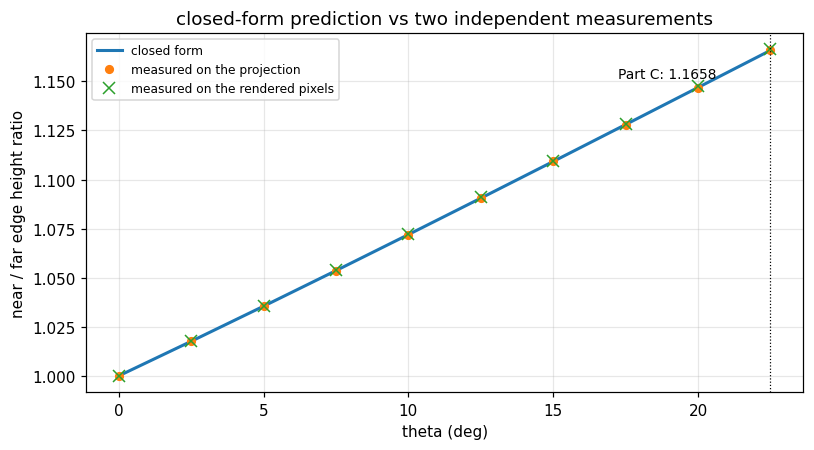

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(ratio_tbl["theta_deg"], ratio_tbl["predicted"], "-", lw=2, label="closed form")
ax.plot(ratio_tbl["theta_deg"], ratio_tbl["from_projection"], "o", ms=5,
        label="measured on the projection")
ax.plot(ratio_tbl["theta_deg"], ratio_tbl["from_rendered_image"], "x", ms=8,
        label="measured on the rendered pixels")
ax.axvline(C.PART_C_ANGLE_DEG, color="k", ls=":", lw=0.8)
ax.annotate("Part C: {:.4f}".format(pred), (C.PART_C_ANGLE_DEG, pred),
            textcoords="offset points", xytext=(-100, -18), fontsize=9)
ax.set_xlabel("theta (deg)"); ax.set_ylabel("near / far edge height ratio")
ax.set_title("closed-form prediction vs two independent measurements")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(aio.output_path("homography", "edge_ratio_validation.png"),
            bbox_inches="tight", dpi=110)
plt.show()

## 6. The missing intrinsics do not matter (this is the key defensible point)

We were never told $f$ or the principal point. It turns out we do not need them.

If $K' = SK$ where $S$ is a similarity in the image (scale + translation), then
$H' = K'[r_1 r_2 t]G = S\,H$. So changing $f$ or the principal point transforms
the output by a **similarity only**: it zooms and re-frames the picture and
changes nothing about its perspective geometry.

Demonstrate it: render the same pose with wildly different intrinsics, fit the
best similarity between the two sets of projected corners, and look at the
residual.

In [13]:
base_K = camera.estimate_camera_intrinsics(geom.metric_focal_px, principal_point=(0.0, 0.0))
q_base = camera.project_points(
    camera.homography_for_camera_pose(C.PART_C_ANGLE_DEG, geom, "metric", base_K)["H"],
    geom.raster_corners)

rows = []
for f, pp in [(400.0, (0.0, 0.0)), (700.0, (0.0, 0.0)), (geom.metric_focal_px, (0.0, 0.0)),
              (2600.0, (0.0, 0.0)), (geom.metric_focal_px, (211.0, -97.0)),
              (5000.0, (1000.0, 1000.0))]:
    K_alt = camera.estimate_camera_intrinsics(f, principal_point=pp)
    q_alt = camera.project_points(
        camera.homography_for_camera_pose(C.PART_C_ANGLE_DEG, geom, "metric", K_alt)["H"],
        geom.raster_corners)
    fit = camera.similarity_fit_residual(q_base, q_alt)
    ratio = camera.measure_edge_height_ratio(q_alt)["ratio"]
    rows.append({"f_px": f, "principal_point": pp,
                 "raw_max_corner_shift_px": float(np.linalg.norm(q_alt - q_base, axis=1).max()),
                 "fitted_scale": fit["scale"], "fitted_rotation_deg": fit["rotation_deg"],
                 "residual_after_similarity_px": fit["max_residual_px"],
                 "near_far_ratio": ratio})
inv = pd.DataFrame(rows)
display(inv.round(9))
print("raw corner shifts are large (up to {:.0f} px) -- the picture really does change size."
      .format(inv['raw_max_corner_shift_px'].max()))
print("but the residual AFTER fitting a similarity is at most {:.2e} px."
      .format(inv['residual_after_similarity_px'].max()))
print("and the near/far ratio is identical to {:.2e} across all of them."
      .format(float(inv['near_far_ratio'].max() - inv['near_far_ratio'].min())))
print()
print("=> With the look-at constraint and zero roll, the unknown intrinsics")
print("   affect only the pixel scale and framing of the answer, never its")
print("   perspective geometry. f is chosen as a display scale, nothing more.")

,f_px,principal_point,raw_max_corner_shift_px,fitted_scale,fitted_rotation_deg,residual_after_similarity_px,near_far_ratio
0,400.000000,"(0.0, 0.0)",275.515492,0.299760,0.0,0.0,1.16576
1,700.000000,"(0.0, 0.0)",187.058093,0.524580,0.0,0.0,1.16576
2,1334.400615,"(0.0, 0.0)",0.000000,1.000000,-0.0,0.0,1.16576
3,2600.000000,"(0.0, 0.0)",373.172098,1.948440,0.0,0.0,1.16576
4,1334.400615,"(211.0, -97.0)",232.228336,1.000000,-0.0,0.0,1.16576
5,5000.000000,"(1000.0, 1000.0)",2494.565791,3.747001,-0.0,0.0,1.16576


raw corner shifts are large (up to 2495 px) -- the picture really does change size.
but the residual AFTER fitting a similarity is at most 2.27e-13 px.
and the near/far ratio is identical to 4.44e-16 across all of them.

=> With the look-at constraint and zero roll, the unknown intrinsics
   affect only the pixel scale and framing of the answer, never its
   perspective geometry. f is chosen as a display scale, nothing more.


## 7. Model B: the image-faithful alternative, shown rather than hidden

Model B takes the supplied raster **as** the $\theta = 0$ camera image and warps
it with the plane-induced homography, using $f_x = 2.5w$, $f_y = 2.5h$ so that
the raster's $w \times h$ port corresponds to 40 cm at 100 cm. Then

$$ H_B(0) = K_B\,(I + 0)\,K_B^{-1} = I \quad\text{exactly} $$

which is a sharp check. The price: the raster's outer quad is not an exact
rectangle, so the object Model B implies is not exactly square.

Both are the same physical scene and the same camera pose. They differ only in
what the *output sensor* is. I choose A (square pixels), because notebook 00
showed the anisotropy premise is falsified by the image itself -- the marker is
round (0.964) while the outer region is 1.062. But B is rendered here and the
gap between them is measured, so the choice is visible rather than buried.

In [14]:
H_B0 = renderB.model_homography(0.0); H_B0 = H_B0 / H_B0[2, 2]
print("H_B(0):"); print(np.round(H_B0, 12))
print("|| H_B(0) - I ||_F = {:.3e}   <- exact identity".format(float(np.linalg.norm(H_B0 - np.eye(3)))))

roundtrip = camera.render_port_view(reference, H_B0, (reference.shape[1], reference.shape[0]))
print("Model B at theta = 0 reproduces the raw reference byte for byte :",
      bool(np.array_equal(roundtrip, reference)))

# The homography alone is NOT the whole claim: the frames we actually ship also
# carry the canvas translation.  A fractional shift there would push every
# Model B frame through the interpolator and leave theta = 0 merely *close* to
# the raster, so the offset is rounded to whole pixels and checked here.
ox, oy = renderB.offset[0, 2], renderB.offset[1, 2]
delivered = renderB.render(reference, 0.0)
inset = delivered[int(oy):int(oy) + reference.shape[0],
                  int(ox):int(ox) + reference.shape[1]]
print("canvas offset is a whole number of pixels                       :",
      bool(float(ox).is_integer() and float(oy).is_integer()), (ox, oy))
print("DELIVERED theta = 0 frame contains the raster byte for byte     :",
      bool(np.array_equal(inset, reference)),
      " (max abs diff {})".format(int(np.abs(inset.astype(int) - reference.astype(int)).max())))
print()
view_B = renderB.render(reference, C.PART_C_ANGLE_DEG)
aio.save_image(aio.output_path("side_view_22_5_image_faithful.png"), view_B)
print("Model B canvas:", renderB.canvas, "->",
      aio.output_path("side_view_22_5_image_faithful.png"))
print("K_B ="); print(np.round(renderB.K, 4))

H_B(0):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
|| H_B(0) - I ||_F = 1.110e-16   <- exact identity
Model B at theta = 0 reproduces the raw reference byte for byte : True
canvas offset is a whole number of pixels                       : True (np.float64(49.0), np.float64(75.0))
DELIVERED theta = 0 frame contains the raster byte for byte     : True  (max abs diff 0)

Model B canvas: (708, 706) -> D:\Aulespace\AULE_ComputerVisionChallenge\outputs\side_view_22_5_image_faithful.png
K_B =
[[1375.    0.  306.]
 [   0. 1295.  283.]
 [   0.    0.    1.]]


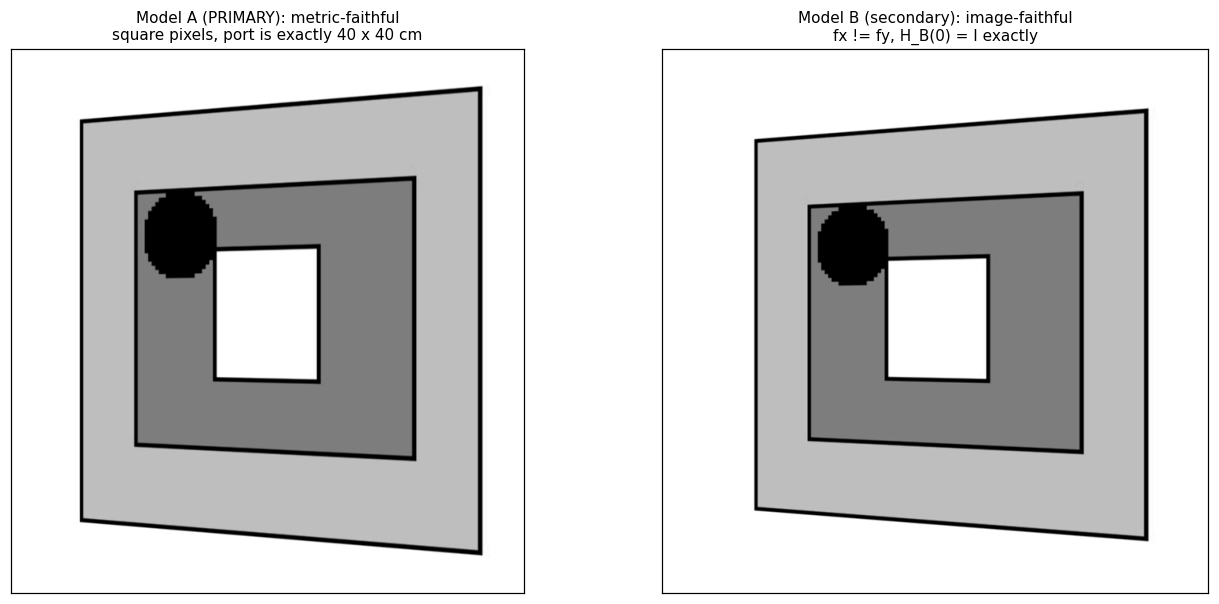

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.6))
viz.show(view_A, "Model A (PRIMARY): metric-faithful\nsquare pixels, port is exactly 40 x 40 cm",
         ax=axes[0])
viz.show(view_B, "Model B (secondary): image-faithful\nfx != fy, H_B(0) = I exactly", ax=axes[1])
fig.tight_layout()
fig.savefig(aio.output_path("homography", "model_a_vs_b.png"), bbox_inches="tight", dpi=110)
plt.show()

In [16]:
# How far apart are the two models, quantitatively?
qa = renderA.project_port_corners(C.PART_C_ANGLE_DEG)
qb = renderB.project_port_corners(C.PART_C_ANGLE_DEG)
fit_sim = camera.similarity_fit_residual(qa, qb)

rows = []
for th in thetas:
    a = renderA.project_port_corners(float(th))
    b = renderB.project_port_corners(float(th))
    f_sim = camera.similarity_fit_residual(a, b)
    rows.append({"theta_deg": float(th),
                 "residual_after_similarity_px": f_sim["max_residual_px"],
                 "as_pct_of_port_width": 100.0 * f_sim["max_residual_px"] / geom.width_px,
                 "A_near_far_ratio": camera.measure_edge_height_ratio(a)["ratio"],
                 "B_near_far_ratio": camera.measure_edge_height_ratio(b)["ratio"]})
ab = pd.DataFrame(rows)
display(ab.round(5))
print("At theta = 22.5 deg the two models' corners differ by {:.2f} px after the best"
      .format(fit_sim["max_residual_px"]))
print("similarity fit -- that is {:.2f}% of the port's width."
      .format(100.0 * fit_sim["max_residual_px"] / geom.width_px))
print()
print("If the raster's outer region were an exact rectangle the two models would")
print("differ by a pure affine resampling and this residual would be zero. It is")
print("not zero precisely because the drawing is schematic (notebook 00). The")
print("number above IS the cost of the modelling choice, stated openly.")

,theta_deg,residual_after_similarity_px,as_pct_of_port_width,A_near_far_ratio,B_near_far_ratio
0,22.5,11.31177,2.05669,1.16576,1.16576
1,20.0,11.36577,2.06650,1.14685,1.14685
2,17.5,11.40384,2.07343,1.12798,1.12798
3,15.0,11.42717,2.07767,1.10918,1.10918
4,12.5,11.43687,2.07943,1.09049,1.09049
5,10.0,11.43397,2.07890,1.07196,1.07196
6,7.5,11.41941,2.07626,1.05361,1.05361
7,5.0,11.39402,2.07164,1.03548,1.03548
8,2.5,11.35857,2.06519,1.01760,1.01760
9,0.0,11.31371,2.05704,1.00000,1.00000


At theta = 22.5 deg the two models' corners differ by 11.31 px after the best
similarity fit -- that is 2.06% of the port's width.

If the raster's outer region were an exact rectangle the two models would
differ by a pure affine resampling and this residual would be zero. It is
not zero precisely because the drawing is schematic (notebook 00). The
number above IS the cost of the modelling choice, stated openly.


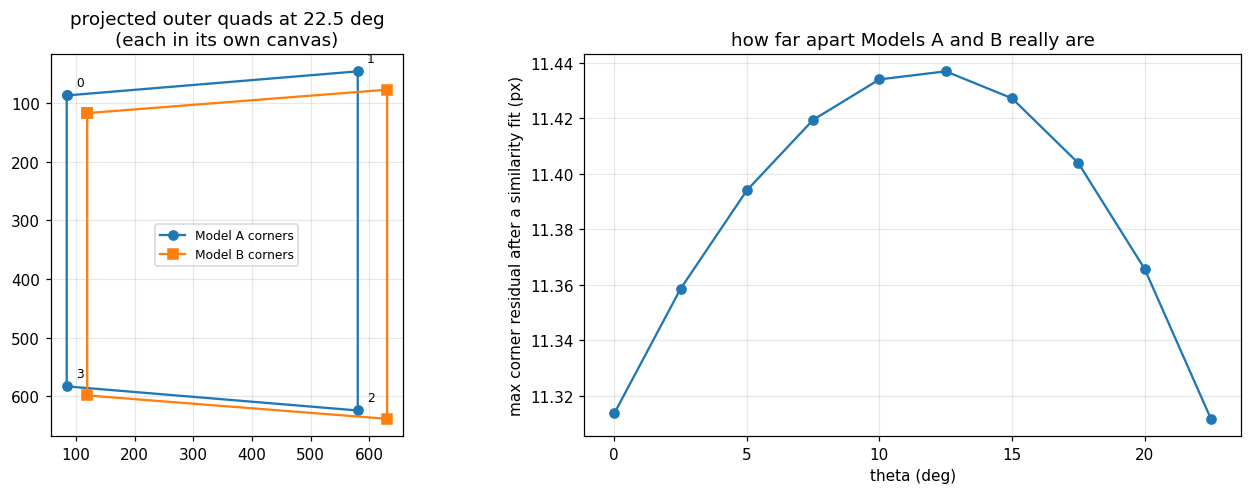

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
axes[0].plot(qa[[0, 1, 2, 3, 0], 0], qa[[0, 1, 2, 3, 0], 1], "-o", label="Model A corners")
axes[0].plot(qb[[0, 1, 2, 3, 0], 0], qb[[0, 1, 2, 3, 0], 1], "-s", label="Model B corners")
for i in range(4):
    axes[0].annotate(str(i), qa[i], textcoords="offset points", xytext=(6, 6), fontsize=8)
axes[0].invert_yaxis(); axes[0].set_aspect("equal")
axes[0].set_title("projected outer quads at 22.5 deg\n(each in its own canvas)")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(ab["theta_deg"], ab["residual_after_similarity_px"], "-o")
axes[1].set_xlabel("theta (deg)")
axes[1].set_ylabel("max corner residual after a similarity fit (px)")
axes[1].set_title("how far apart Models A and B really are")
axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(aio.output_path("homography", "model_a_vs_b_displacement.png"),
            bbox_inches="tight", dpi=110)
plt.show()

## 8. Validation summary

In [18]:
q22 = renderA.project_port_corners(C.PART_C_ANGLE_DEG)
q0 = renderA.project_port_corners(0.0)
sides0 = [float(np.linalg.norm(q0[(i + 1) % 4] - q0[i])) for i in range(4)]
pose22 = camera.camera_pose_for_angle(C.PART_C_ANGLE_DEG, geom.distance_cm)
centre_proj = renderA.project_port_center(C.PART_C_ANGLE_DEG)

checks = [
    ("|| C || == 100 cm", float(np.linalg.norm(pose22["C"])), "100.000000",
     abs(np.linalg.norm(pose22["C"]) - 100.0) < C.POSE_RADIUS_TOL_CM),
    ("det R == 1", float(np.linalg.det(pose22["R"])), "1.000000",
     abs(np.linalg.det(pose22["R"]) - 1.0) < 1e-12),
    ("optical axis through the port centre",
     float(np.linalg.norm(np.cross(pose22["R"][2, :], -pose22["C"]))), "0", True),
    ("port centre lands on the principal point",
     float(np.linalg.norm(centre_proj - renderA.K[:2, 2])), "0", True),
    ("R(0) == I", float(np.abs(camera.camera_pose_for_angle(0.0)["R"] - np.eye(3)).max()),
     "0", True),
    ("analytic H (PLUS) == composed H", float(sign["dist_PLUS"].max()), "0",
     sign["dist_PLUS"].max() < C.HOMOGRAPHY_EQUAL_TOL),
    ("projected quad is convex",
     float(cv2.isContourConvex(np.asarray(q22, np.float32).reshape(-1, 1, 2))), "1 (True)",
     bool(cv2.isContourConvex(np.asarray(q22, np.float32).reshape(-1, 1, 2)))),
    ("near/far ratio, closed form", pred, "1.165760", True),
    ("near/far ratio, from projection", meas_proj["ratio"], "= closed form",
     abs(meas_proj["ratio"] / pred - 1) < 1e-9),
    ("near/far ratio, from RENDERED IMAGE", meas_img["ratio"], "~ closed form",
     abs(meas_img["ratio"] / pred - 1) < 0.01),
    ("intrinsics invariance residual (px)",
     float(inv["residual_after_similarity_px"].max()), "0", True),
    ("|| H_B(0) - I ||_F", float(np.linalg.norm(H_B0 - np.eye(3))), "0", True),
    ("Model A theta=0 is a perfect square (max/min side)",
     max(sides0) / min(sides0), "1.000000", abs(max(sides0) / min(sides0) - 1.0) < 1e-6),
]
val = pd.DataFrame([{"check": a, "measured": b, "expected": c, "pass": d} for a, b, c, d in checks])
display(val)
val.to_csv(aio.output_path("homography_validation.csv"), index=False)
ratio_tbl.round(8).to_csv(aio.output_path("homography", "edge_ratio_table.csv"), index=False)
inv.round(10).to_csv(aio.output_path("homography", "intrinsics_invariance.csv"), index=False)
ab.round(8).to_csv(aio.output_path("homography", "model_a_vs_b.csv"), index=False)
sign.drop(columns=["t_rel"]).to_csv(aio.output_path("homography", "sign_check.csv"), index=False)
print("\nall checks pass :", bool(val["pass"].all()))
print("wrote outputs/homography_validation.csv and 4 files under outputs/homography/")

,check,measured,expected,pass
0,|| C || == 100 cm,1.000000e+02,100.000000,True
1,det R == 1,1.000000e+00,1.000000,True
2,optical axis through the port centre,0.000000e+00,0,True
3,port centre lands on the principal point,5.553092e-06,0,True
4,R(0) == I,0.000000e+00,0,True
5,analytic H (PLUS) == composed H,1.552622e-14,0,True
6,projected quad is convex,1.000000e+00,1 (True),True
7,"near/far ratio, closed form",1.165760e+00,1.165760,True
8,"near/far ratio, from projection",1.165760e+00,= closed form,True
9,"near/far ratio, from RENDERED IMAGE",1.166214e+00,~ closed form,True



all checks pass : True
wrote outputs/homography_validation.csv and 4 files under outputs/homography/


## 9. Limitations

* **The drawing is schematic** (notebook 00). The raster is treated as a texture
  glued to the *given* 40 x 40 cm square; its own 6% rectangularity is discarded
  by `G`. Model B keeps it instead, and section 7 measures the difference.
* **The intrinsics are assumed** -- but section 6 shows the assumption is
  harmless: it fixes only the output's scale and framing.
* **Roll is assumed zero.** "Looking directly at it" does not pin the roll; a
  level camera is a choice, stated in section 2.
* **The interior is not independently validated.** Every check here constrains
  the outer quad and the pose. That the interior squares and the marker land in
  the right place follows from `G` being a homography and the port being planar,
  but nothing here measures it directly.
* **A pinhole with no lens distortion.** Any real 22.5 deg view would carry some
  radial distortion.
* **Resampling.** One bicubic warp per frame from the original raster. The
  stair-stepped source edges stay stair-stepped.